# Analyze Gold Trends

This notebook analyzes validated Gold pageview aggregates through the DuckDB serving database. It is designed for repeatable analysis and paper-ready exports without scanning Bronze or Silver data.

Default behavior reads only `data/processed/serving/wikitrend.duckdb` and writes analysis artifacts to `paper/tables/` and `paper/figures/`.


## Analysis Contract

- Source of truth: DuckDB serving views over validated Gold Parquet.
- No raw Bronze or row-level Silver reads.
- Export deterministic tables as CSV and figures as PNG.
- Keep all assumptions visible in the notebook.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

SERVING_DB = ROOT / "data" / "processed" / "serving" / "wikitrend.duckdb"
GOLD_VALIDATION_REPORT = ROOT / "data" / "processed" / "validation" / "gold_pageviews_validation.json"
TABLE_DIR = ROOT / "paper" / "tables"
FIGURE_DIR = ROOT / "paper" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("ggplot")

assert SERVING_DB.exists(), f"Serving database is missing: {SERVING_DB}"
assert GOLD_VALIDATION_REPORT.exists(), f"Gold validation report is missing: {GOLD_VALIDATION_REPORT}"

with GOLD_VALIDATION_REPORT.open(encoding="utf-8-sig") as handle:
    gold_validation = json.load(handle)
assert gold_validation["status"] == "pass", gold_validation

con = duckdb.connect(str(SERVING_DB), read_only=True)


## Serving Database Sanity Checks


In [2]:
serving_tables = con.execute("show all tables").fetchdf()
serving_build = con.execute("select * from metadata.serving_build").fetchdf()
inventory = con.execute("select * from metadata.gold_table_inventory order by table_name").fetchdf()

expected_views = {
    "gold.hourly_project_access": 504,
    "gold.daily_project_access": 21,
    "gold.top_pages_hourly": 50400,
}
actual_counts = {
    view_name: con.execute(f"select count(*) from {view_name}").fetchone()[0]
    for view_name in expected_views
}
assert actual_counts == expected_views, actual_counts

analysis_scope = pd.DataFrame(
    [
        {"metric": "database", "value": str(SERVING_DB.relative_to(ROOT))},
        {"metric": "database_size_mb", "value": round(SERVING_DB.stat().st_size / 1024 / 1024, 3)},
        {"metric": "gold_validation_status", "value": gold_validation["status"]},
        {"metric": "hourly_rows", "value": actual_counts["gold.hourly_project_access"]},
        {"metric": "daily_rows", "value": actual_counts["gold.daily_project_access"]},
        {"metric": "top_page_rows", "value": actual_counts["gold.top_pages_hourly"]},
    ]
)
analysis_scope.to_csv(TABLE_DIR / "analysis_scope.csv", index=False)

display(serving_tables)
display(serving_build)
display(inventory)
analysis_scope


,database,schema,name,column_names,column_types,temporary
0,wikitrend,gold,daily_project_access,"[date, project, access_mode, page_rows, total_...","[DATE, VARCHAR, VARCHAR, BIGINT, BIGINT, BIGIN...",False
1,wikitrend,gold,hourly_project_access,"[date, hour, project, access_mode, page_rows, ...","[DATE, SMALLINT, VARCHAR, VARCHAR, BIGINT, BIG...",False
2,wikitrend,gold,top_pages_hourly,"[date, hour, project, access_mode, source_proj...","[DATE, SMALLINT, VARCHAR, VARCHAR, VARCHAR, VA...",False
3,wikitrend,metadata,gold_table_inventory,"[table_name, view_name, grain, row_count, parq...","[VARCHAR, VARCHAR, VARCHAR, BIGINT, VARCHAR]",False
4,wikitrend,metadata,serving_build,"[generated_at_utc, database_path, gold_dir, va...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR]",False


,generated_at_utc,database_path,gold_dir,validation_report_path,storage_mode
0,2026-08-24T17:42:04Z,D:/Tâm-WikiTrend/data/processed/serving/wikitr...,D:/Tâm-WikiTrend/data/processed/gold,data\processed\validation\gold_pageviews_valid...,view


,table_name,view_name,grain,row_count,parquet_glob
0,daily_project_access,gold.daily_project_access,"date, project, access_mode",21,D:/Tâm-WikiTrend/data/processed/gold/daily_pro...
1,hourly_project_access,gold.hourly_project_access,"date, hour, project, access_mode",504,D:/Tâm-WikiTrend/data/processed/gold/hourly_pr...
2,top_pages_hourly,gold.top_pages_hourly,"date, hour, project, access_mode, rank_in_hour",50400,D:/Tâm-WikiTrend/data/processed/gold/top_pages...


,metric,value
0,database,data\processed\serving\wikitrend.duckdb
1,database_size_mb,0.76
2,gold_validation_status,pass
3,hourly_rows,504
4,daily_rows,21
5,top_page_rows,50400


## Project and Access Summary


In [3]:
project_access_summary = con.execute(
    """
    select
        project,
        access_mode,
        count(*) as hourly_observations,
        sum(page_rows) as page_rows,
        sum(total_views) as total_views,
        sum(total_response_size) as total_response_size,
        avg(total_views) as avg_hourly_views,
        stddev_samp(total_views) as stddev_hourly_views,
        max(total_views) as peak_hourly_views,
        min(total_views) as min_hourly_views,
        max(max_page_views) as max_single_page_views,
        avg(approx_distinct_pages) as avg_approx_distinct_pages
    from gold.hourly_project_access
    group by 1, 2
    order by total_views desc
    """
).fetchdf()
project_access_summary["views_per_page_row"] = (
    project_access_summary["total_views"] / project_access_summary["page_rows"]
)
project_access_summary.to_csv(TABLE_DIR / "project_access_summary.csv", index=False)
project_access_summary


,project,access_mode,hourly_observations,page_rows,total_views,total_response_size,avg_hourly_views,stddev_hourly_views,peak_hourly_views,min_hourly_views,max_single_page_views,avg_approx_distinct_pages,views_per_page_row
0,en,mobile,72,85323663.00,513735205.00,0.00,7135211.18,1434958.62,9401263,4756996,217117,1203332.00,6.02
1,en,desktop,72,71560348.00,222927754.00,0.00,3096218.81,705206.01,4375963,1902476,236178,1002399.32,3.12
2,commons,desktop,72,7223274.00,9795529.00,0.00,136049.01,29120.20,213380,94393,4293,101740.21,1.36
3,commons,mobile,72,3130826.00,4739553.00,0.00,65827.12,16405.15,120651,44323,1975,44543.38,1.51
4,vi,mobile,72,1358846.00,2933827.00,0.00,40747.60,16568.15,69117,11706,2005,17453.65,2.16
5,wikidata,desktop,72,1594039.00,2110030.00,0.00,29305.97,4108.30,39103,19521,3127,23079.24,1.32
6,vi,desktop,72,935826.00,1309708.00,0.00,18190.39,8032.54,38937,5091,1476,12786.01,1.40


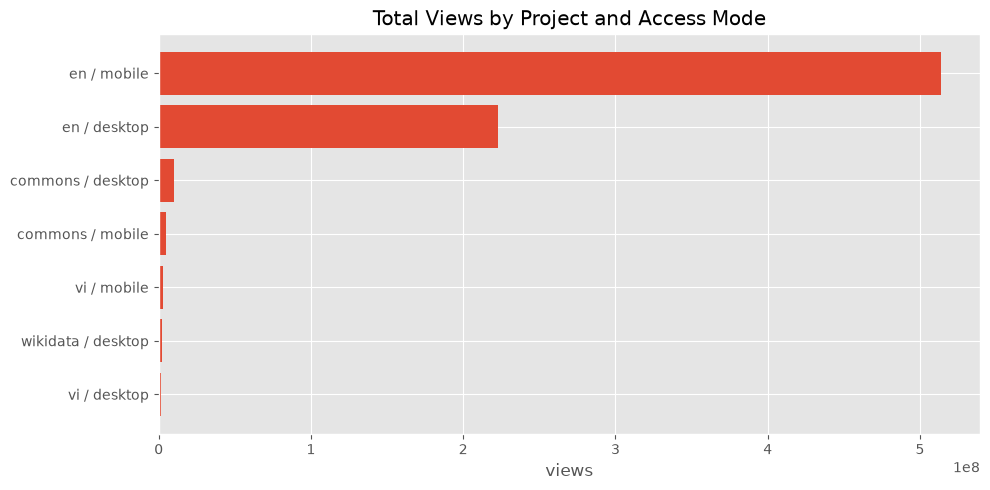

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = project_access_summary.sort_values("total_views", ascending=True).copy()
plot_df["segment"] = plot_df["project"] + " / " + plot_df["access_mode"]
ax.barh(plot_df["segment"], plot_df["total_views"])
ax.set_title("Total Views by Project and Access Mode")
ax.set_xlabel("views")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "total_views_by_project_access.png", dpi=160)
plt.show()


## Mobile vs Desktop Mix


In [5]:
mobile_desktop_mix = con.execute(
    """
    with totals as (
        select project, access_mode, sum(total_views) as total_views
        from gold.daily_project_access
        group by 1, 2
    ), pivoted as (
        select
            project,
            sum(case when access_mode = 'mobile' then total_views else 0 end) as mobile_views,
            sum(case when access_mode = 'desktop' then total_views else 0 end) as desktop_views,
            sum(total_views) as total_views
        from totals
        group by 1
    )
    select
        project,
        mobile_views,
        desktop_views,
        total_views,
        mobile_views / nullif(total_views, 0) as mobile_share,
        desktop_views / nullif(total_views, 0) as desktop_share,
        mobile_views / nullif(desktop_views, 0) as mobile_to_desktop_ratio
    from pivoted
    order by total_views desc
    """
).fetchdf()
mobile_desktop_mix.to_csv(TABLE_DIR / "mobile_desktop_mix.csv", index=False)
mobile_desktop_mix


,project,mobile_views,desktop_views,total_views,mobile_share,desktop_share,mobile_to_desktop_ratio
0,en,513735205.00,222927754.00,736662959.00,0.70,0.30,2.30
1,commons,4739553.00,9795529.00,14535082.00,0.33,0.67,0.48
2,vi,2933827.00,1309708.00,4243535.00,0.69,0.31,2.24
3,wikidata,0.00,2110030.00,2110030.00,0.00,1.00,0.00


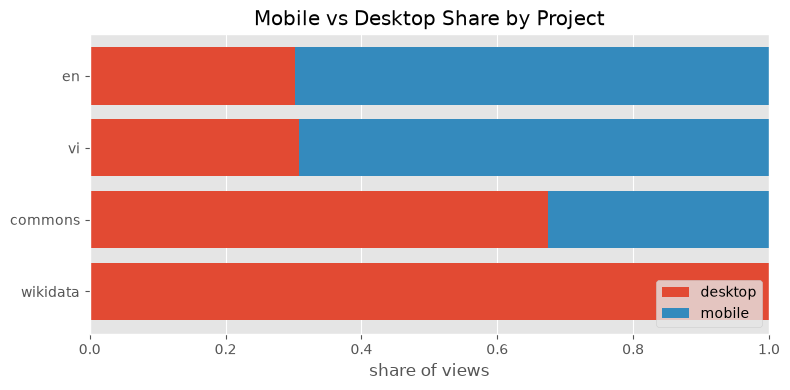

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
share_df = mobile_desktop_mix.sort_values("mobile_share", ascending=True)
ax.barh(share_df["project"], share_df["desktop_share"], label="desktop")
ax.barh(
    share_df["project"],
    share_df["mobile_share"],
    left=share_df["desktop_share"],
    label="mobile",
)
ax.set_title("Mobile vs Desktop Share by Project")
ax.set_xlabel("share of views")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mobile_desktop_share_by_project.png", dpi=160)
plt.show()


## Hourly Trend Analysis


In [7]:
hourly_trend = con.execute(
    """
    select
        cast(date as timestamp) + hour * interval '1 hour' as timestamp_utc,
        project,
        access_mode,
        total_views,
        page_rows,
        total_response_size,
        approx_distinct_pages
    from gold.hourly_project_access
    order by 1, 2, 3
    """
).fetchdf()

hourly_total_trend = con.execute(
    """
    select
        cast(date as timestamp) + hour * interval '1 hour' as timestamp_utc,
        sum(total_views) as total_views,
        sum(page_rows) as page_rows,
        sum(total_response_size) as total_response_size
    from gold.hourly_project_access
    group by 1
    order by 1
    """
).fetchdf()

peak_hours = con.execute(
    """
    select
        cast(date as timestamp) + hour * interval '1 hour' as timestamp_utc,
        project,
        access_mode,
        total_views,
        rank() over (partition by project, access_mode order by total_views desc) as rank_in_segment
    from gold.hourly_project_access
    qualify rank_in_segment <= 3
    order by project, access_mode, rank_in_segment
    """
).fetchdf()

hourly_trend.to_csv(TABLE_DIR / "hourly_project_access_trend.csv", index=False)
hourly_total_trend.to_csv(TABLE_DIR / "hourly_total_trend.csv", index=False)
peak_hours.to_csv(TABLE_DIR / "peak_hours_by_project_access.csv", index=False)

display(hourly_total_trend.head())
peak_hours


,timestamp_utc,total_views,page_rows,total_response_size
0,2026-01-01 00:00:00,10694842.00,2207366.00,0.00
1,2026-01-01 01:00:00,10927868.00,2200829.00,0.00
2,2026-01-01 02:00:00,10086501.00,2179153.00,0.00
3,2026-01-01 03:00:00,9971705.00,2128865.00,0.00
4,2026-01-01 04:00:00,9630250.00,2075434.00,0.00


,timestamp_utc,project,access_mode,total_views,rank_in_segment
0,2026-01-02 15:00:00,commons,desktop,213380,1
1,2026-01-02 14:00:00,commons,desktop,208061,2
2,2026-01-02 13:00:00,commons,desktop,206947,3
3,2026-01-03 15:00:00,commons,mobile,120651,1
4,2026-01-03 18:00:00,commons,mobile,104426,2
5,2026-01-03 23:00:00,commons,mobile,99132,3
6,2026-01-02 06:00:00,en,desktop,4375963,1
7,2026-01-02 08:00:00,en,desktop,4352026,2
8,2026-01-02 05:00:00,en,desktop,4322750,3
9,2026-01-03 22:00:00,en,mobile,9401263,1


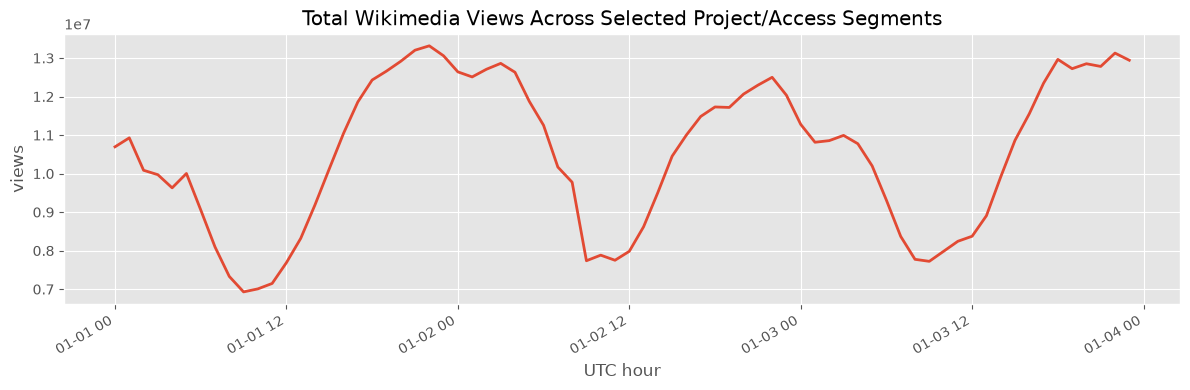

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_total_trend["timestamp_utc"], hourly_total_trend["total_views"], linewidth=2)
ax.set_title("Total Wikimedia Views Across Selected Project/Access Segments")
ax.set_xlabel("UTC hour")
ax.set_ylabel("views")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "hourly_total_views_trend.png", dpi=160)
plt.show()


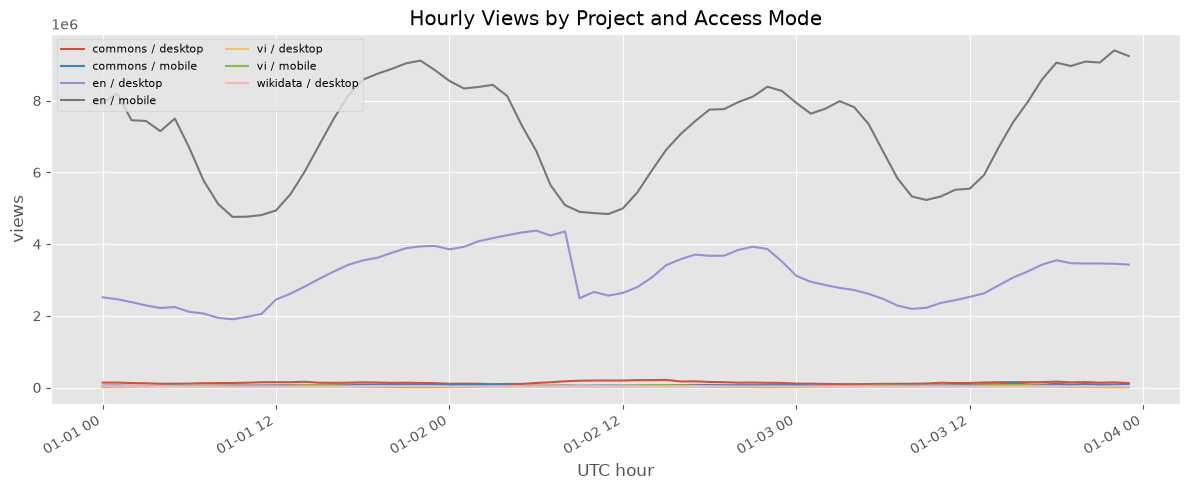

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for (project, access_mode), frame in hourly_trend.groupby(["project", "access_mode"]):
    label = f"{project} / {access_mode}"
    ax.plot(frame["timestamp_utc"], frame["total_views"], linewidth=1.5, label=label)
ax.set_title("Hourly Views by Project and Access Mode")
ax.set_xlabel("UTC hour")
ax.set_ylabel("views")
ax.legend(ncol=2, fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "hourly_views_by_project_access.png", dpi=160)
plt.show()


## Volatility Analysis


In [10]:
volatility = con.execute(
    """
    select
        project,
        access_mode,
        count(*) as hourly_observations,
        avg(total_views) as mean_hourly_views,
        stddev_samp(total_views) as stddev_hourly_views,
        min(total_views) as min_hourly_views,
        max(total_views) as max_hourly_views,
        (max(total_views) - min(total_views)) as hourly_range_views,
        stddev_samp(total_views) / nullif(avg(total_views), 0) as coefficient_of_variation
    from gold.hourly_project_access
    group by 1, 2
    order by coefficient_of_variation desc nulls last
    """
).fetchdf()
volatility.to_csv(TABLE_DIR / "hourly_volatility_by_project_access.csv", index=False)
volatility


,project,access_mode,hourly_observations,mean_hourly_views,stddev_hourly_views,min_hourly_views,max_hourly_views,hourly_range_views,coefficient_of_variation
0,vi,desktop,72,18190.39,8032.54,5091,38937,33846,0.44
1,vi,mobile,72,40747.60,16568.15,11706,69117,57411,0.41
2,commons,mobile,72,65827.12,16405.15,44323,120651,76328,0.25
3,en,desktop,72,3096218.81,705206.01,1902476,4375963,2473487,0.23
4,commons,desktop,72,136049.01,29120.20,94393,213380,118987,0.21
5,en,mobile,72,7135211.18,1434958.62,4756996,9401263,4644267,0.20
6,wikidata,desktop,72,29305.97,4108.30,19521,39103,19582,0.14


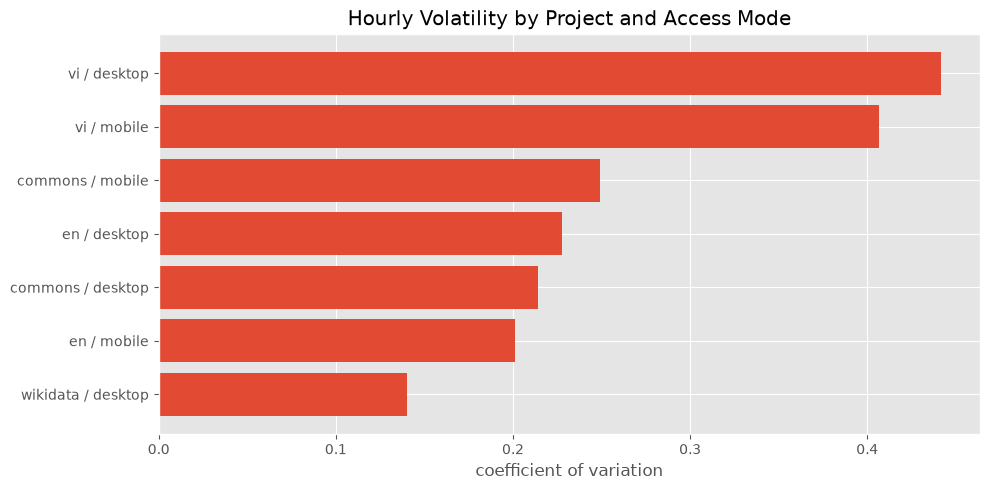

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
vol_plot = volatility.sort_values("coefficient_of_variation", ascending=True).copy()
vol_plot["segment"] = vol_plot["project"] + " / " + vol_plot["access_mode"]
ax.barh(vol_plot["segment"], vol_plot["coefficient_of_variation"])
ax.set_title("Hourly Volatility by Project and Access Mode")
ax.set_xlabel("coefficient of variation")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "hourly_volatility_by_project_access.png", dpi=160)
plt.show()


## Top-Page Concentration


In [12]:
top_page_concentration = con.execute(
    """
    with ranked as (
        select date, hour, project, access_mode, rank_in_hour, view_count
        from gold.top_pages_hourly
    ), concentration as (
        select
            date,
            hour,
            project,
            access_mode,
            sum(case when rank_in_hour <= 1 then view_count else 0 end) as top_1_views,
            sum(case when rank_in_hour <= 10 then view_count else 0 end) as top_10_views,
            sum(case when rank_in_hour <= 100 then view_count else 0 end) as top_100_views
        from ranked
        group by 1, 2, 3, 4
    ), hourly_totals as (
        select date, hour, project, access_mode, total_views
        from gold.hourly_project_access
    )
    select
        c.date,
        c.hour,
        c.project,
        c.access_mode,
        h.total_views,
        c.top_1_views,
        c.top_10_views,
        c.top_100_views,
        c.top_1_views / nullif(h.total_views, 0) as top_1_share,
        c.top_10_views / nullif(h.total_views, 0) as top_10_share,
        c.top_100_views / nullif(h.total_views, 0) as top_100_share
    from concentration c
    join hourly_totals h using (date, hour, project, access_mode)
    order by c.date, c.hour, c.project, c.access_mode
    """
).fetchdf()

concentration_summary = (
    top_page_concentration.groupby(["project", "access_mode"], as_index=False)
    .agg(
        avg_top_1_share=("top_1_share", "mean"),
        avg_top_10_share=("top_10_share", "mean"),
        avg_top_100_share=("top_100_share", "mean"),
        max_top_1_share=("top_1_share", "max"),
        max_top_10_share=("top_10_share", "max"),
        max_top_100_share=("top_100_share", "max"),
    )
    .sort_values("avg_top_100_share", ascending=False)
)

top_page_concentration.to_csv(TABLE_DIR / "top_page_concentration_hourly.csv", index=False)
concentration_summary.to_csv(TABLE_DIR / "top_page_concentration_summary.csv", index=False)
concentration_summary


,project,access_mode,avg_top_1_share,avg_top_10_share,avg_top_100_share,max_top_1_share,max_top_10_share,max_top_100_share
1,commons,mobile,0.02,0.06,0.13,0.03,0.08,0.17
5,vi,mobile,0.02,0.06,0.13,0.05,0.12,0.20
2,en,desktop,0.06,0.08,0.11,0.09,0.12,0.16
0,commons,desktop,0.02,0.07,0.10,0.03,0.08,0.15
6,wikidata,desktop,0.04,0.07,0.10,0.11,0.15,0.18
4,vi,desktop,0.02,0.05,0.10,0.07,0.13,0.19
3,en,mobile,0.02,0.04,0.09,0.02,0.08,0.16


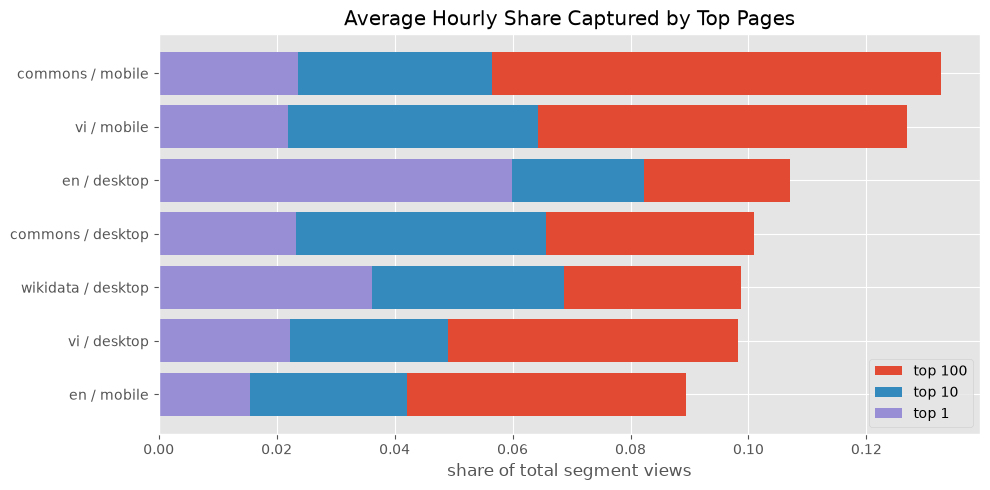

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
conc_plot = concentration_summary.sort_values("avg_top_100_share", ascending=True).copy()
conc_plot["segment"] = conc_plot["project"] + " / " + conc_plot["access_mode"]
ax.barh(conc_plot["segment"], conc_plot["avg_top_100_share"], label="top 100")
ax.barh(conc_plot["segment"], conc_plot["avg_top_10_share"], label="top 10")
ax.barh(conc_plot["segment"], conc_plot["avg_top_1_share"], label="top 1")
ax.set_title("Average Hourly Share Captured by Top Pages")
ax.set_xlabel("share of total segment views")
ax.set_ylabel("")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "top_page_concentration_summary.png", dpi=160)
plt.show()


## Top-Page Stability


In [14]:
top_page_stability = con.execute(
    """
    with top_sets as (
        select
            cast(date as timestamp) + hour * interval '1 hour' as timestamp_utc,
            project,
            access_mode,
            normalized_title
        from gold.top_pages_hourly
        where rank_in_hour <= 100
    ), adjacent_pairs as (
        select
            current.timestamp_utc,
            current.project,
            current.access_mode,
            current.normalized_title,
            previous.normalized_title as previous_normalized_title
        from top_sets current
        left join top_sets previous
          on current.project = previous.project
         and current.access_mode = previous.access_mode
         and current.normalized_title = previous.normalized_title
         and current.timestamp_utc = previous.timestamp_utc + interval '1 hour'
    )
    select
        timestamp_utc,
        project,
        access_mode,
        count(*) as current_top_100_pages,
        count(previous_normalized_title) as retained_from_previous_hour,
        count(previous_normalized_title) / nullif(count(*), 0) as retention_rate
    from adjacent_pairs
    group by 1, 2, 3
    order by 1, 2, 3
    """
).fetchdf()

stability_summary = (
    top_page_stability.groupby(["project", "access_mode"], as_index=False)
    .agg(
        avg_retention_rate=("retention_rate", "mean"),
        min_retention_rate=("retention_rate", "min"),
        max_retention_rate=("retention_rate", "max"),
        compared_hours=("retention_rate", "count"),
    )
    .sort_values("avg_retention_rate", ascending=False)
)

top_page_stability.to_csv(TABLE_DIR / "top_page_stability_hourly.csv", index=False)
stability_summary.to_csv(TABLE_DIR / "top_page_stability_summary.csv", index=False)
stability_summary


,project,access_mode,avg_retention_rate,min_retention_rate,max_retention_rate,compared_hours
2,en,desktop,0.81,0.00,0.91,72
3,en,mobile,0.79,0.00,0.93,72
1,commons,mobile,0.71,0.00,0.81,72
5,vi,mobile,0.62,0.00,0.76,72
0,commons,desktop,0.48,0.00,0.66,72
4,vi,desktop,0.38,0.00,0.60,72
6,wikidata,desktop,0.23,0.00,0.33,72


## Most Viewed Top Pages


In [15]:
most_viewed_top_pages = con.execute(
    """
    select
        project,
        access_mode,
        normalized_title,
        page_title,
        count(*) as top_100_appearances,
        sum(view_count) as total_top_page_views,
        min(rank_in_hour) as best_rank,
        max(view_count) as max_hourly_views,
        avg(view_count) as avg_hourly_views_when_ranked
    from gold.top_pages_hourly
    group by 1, 2, 3, 4
    order by total_top_page_views desc, max_hourly_views desc
    limit 50
    """
).fetchdf()
most_viewed_top_pages.to_csv(TABLE_DIR / "most_viewed_top_pages.csv", index=False)
most_viewed_top_pages.head(25)


,project,access_mode,normalized_title,page_title,top_100_appearances,total_top_page_views,best_rank,max_hourly_views,avg_hourly_views_when_ranked
0,en,desktop,Main Page,Main_Page,72,12634565.00,1,236178,175480.07
1,en,mobile,Main Page,Main_Page,72,7550482.00,1,144086,104867.81
2,en,mobile,Nicolás Maduro,Nicolás_Maduro,16,1973115.00,1,217117,123319.69
3,en,desktop,Special:Search,Special:Search,72,1429537.00,2,25663,19854.68
4,en,mobile,Special:Search,Special:Search,72,1096524.00,2,19367,15229.50
5,en,mobile,Stranger Things,Stranger_Things,72,992898.00,2,29522,13790.25
6,en,mobile,Stranger Things season 5,Stranger_Things_season_5,72,820481.00,2,42993,11395.57
7,en,mobile,Wikipedia:Featured pictures,Wikipedia:Featured_pictures,72,793167.00,2,15380,11016.21
8,en,mobile,Venezuela,Venezuela,16,759658.00,2,92312,47478.62
9,en,mobile,Dhurandhar,Dhurandhar,72,712234.00,2,14581,9892.14


## Storage Footprint Summary


In [16]:
def folder_size(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(item.stat().st_size for item in path.rglob("*") if item.is_file())

storage_footprint = pd.DataFrame(
    [
        {"layer": "bronze_raw", "path": "data/raw", "size_bytes": folder_size(ROOT / "data" / "raw")},
        {"layer": "silver_processed", "path": "data/processed/silver", "size_bytes": folder_size(ROOT / "data" / "processed" / "silver")},
        {"layer": "gold_processed", "path": "data/processed/gold", "size_bytes": folder_size(ROOT / "data" / "processed" / "gold")},
        {"layer": "serving_duckdb", "path": "data/processed/serving/wikitrend.duckdb", "size_bytes": SERVING_DB.stat().st_size},
    ]
)
storage_footprint["size_mb"] = storage_footprint["size_bytes"] / 1024 / 1024
storage_footprint["size_gb"] = storage_footprint["size_bytes"] / 1024 / 1024 / 1024
storage_footprint.to_csv(TABLE_DIR / "storage_footprint.csv", index=False)
storage_footprint


,layer,path,size_bytes,size_mb,size_gb
0,bronze_raw,data/raw,3842934231,3664.91,3.58
1,silver_processed,data/processed/silver,5050812635,4816.83,4.70
2,gold_processed,data/processed/gold,1215150,1.16,0.00
3,serving_duckdb,data/processed/serving/wikitrend.duckdb,798720,0.76,0.00


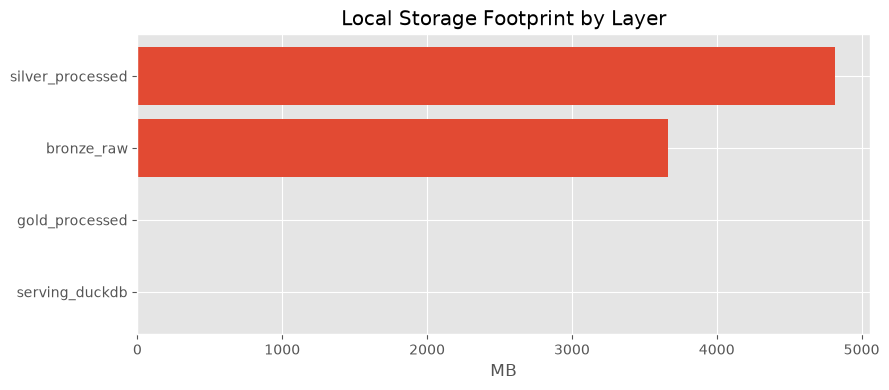

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_storage = storage_footprint.sort_values("size_mb", ascending=True)
ax.barh(plot_storage["layer"], plot_storage["size_mb"])
ax.set_title("Local Storage Footprint by Layer")
ax.set_xlabel("MB")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "storage_footprint_by_layer.png", dpi=160)
plt.show()


## Executive Summary Tables


In [18]:
summary_metrics = pd.DataFrame(
    [
        {"metric": "total_views", "value": int(project_access_summary["total_views"].sum())},
        {"metric": "project_access_segments", "value": int(len(project_access_summary))},
        {"metric": "hours_observed", "value": int(hourly_total_trend["timestamp_utc"].nunique())},
        {
            "metric": "highest_view_segment",
            "value": project_access_summary.iloc[0]["project"]
            + " / "
            + project_access_summary.iloc[0]["access_mode"],
        },
        {"metric": "highest_view_segment_total_views", "value": int(project_access_summary.iloc[0]["total_views"])},
        {
            "metric": "most_volatile_segment",
            "value": volatility.iloc[0]["project"] + " / " + volatility.iloc[0]["access_mode"],
        },
        {
            "metric": "highest_avg_top_100_share_segment",
            "value": concentration_summary.iloc[0]["project"]
            + " / "
            + concentration_summary.iloc[0]["access_mode"],
        },
        {"metric": "serving_db_size_mb", "value": round(SERVING_DB.stat().st_size / 1024 / 1024, 3)},
    ]
)
summary_metrics.to_csv(TABLE_DIR / "executive_summary_metrics.csv", index=False)
summary_metrics


,metric,value
0,total_views,757551606
1,project_access_segments,7
2,hours_observed,72
3,highest_view_segment,en / mobile
4,highest_view_segment_total_views,513735205
5,most_volatile_segment,vi / desktop
6,highest_avg_top_100_share_segment,commons / mobile
7,serving_db_size_mb,0.76


## Export Manifest


In [19]:
export_manifest = pd.DataFrame(
    [
        {"artifact_type": "table", "path": str(path.relative_to(ROOT)), "size_bytes": path.stat().st_size}
        for path in sorted(TABLE_DIR.glob("*.csv"))
    ]
    + [
        {"artifact_type": "figure", "path": str(path.relative_to(ROOT)), "size_bytes": path.stat().st_size}
        for path in sorted(FIGURE_DIR.glob("*.png"))
    ]
)
export_manifest.to_csv(TABLE_DIR / "export_manifest.csv", index=False)
export_manifest


,artifact_type,path,size_bytes
0,table,paper\tables\analysis_scope.csv,170
1,table,paper\tables\executive_summary_metrics.csv,275
2,table,paper\tables\export_manifest.csv,1219
3,table,paper\tables\hourly_project_access_trend.csv,28066
4,table,paper\tables\hourly_total_trend.csv,3342
5,table,paper\tables\hourly_volatility_by_project_acce...,799
6,table,paper\tables\mobile_desktop_mix.csv,431
7,table,paper\tables\most_viewed_top_pages.csv,4391
8,table,paper\tables\peak_hours_by_project_access.csv,959
9,table,paper\tables\project_access_summary.csv,1138


In [20]:
con.close()
print(f"Exported {len(export_manifest)} artifacts")
print(f"Tables: {TABLE_DIR.relative_to(ROOT)}")
print(f"Figures: {FIGURE_DIR.relative_to(ROOT)}")


Exported 22 artifacts
Tables: paper\tables
Figures: paper\figures
